In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import joblib

In [3]:
df = pd.read_csv("/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
print("Shape:", df.shape)
df.info()

Shape: (1470, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLev

In [5]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

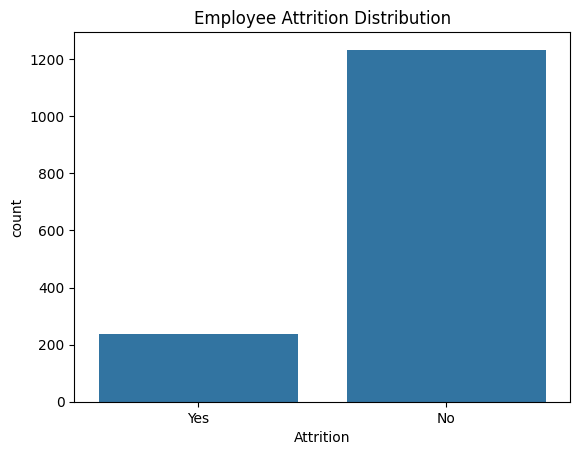

In [6]:
sns.countplot(data=df, x='Attrition')
plt.title('Employee Attrition Distribution')
plt.show()

In [7]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("Constant columns:", constant_cols)

Constant columns: ['EmployeeCount', 'Over18', 'StandardHours']


In [8]:
df = df.drop(columns=constant_cols)

df.shape

(1470, 32)

In [9]:
df = df.drop(columns=['EmployeeNumber'])

df.shape

(1470, 31)

In [10]:
df['Attrition'] = df['Attrition'].map({
    'No': 0,
    'Yes': 1
})

df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [11]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 30)
y shape: (1470,)


In [12]:
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumerical columns:")
print(numerical_cols)

Categorical columns:
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training shape: (1176, 30)
Testing shape: (294, 30)

Training target distribution:
Attrition
0    986
1    190
Name: count, dtype: int64

Testing target distribution:
Attrition
0    247
1     47
Name: count, dtype: int64


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

Model Development

In [15]:
logistic_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

log_pred = logistic_model.predict(X_test)
log_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, log_pred))
print("ROC-AUC:", roc_auc_score(y_test, log_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Accuracy: 0.7517006802721088
ROC-AUC: 0.8031699543457662

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.77      0.84       247
           1       0.35      0.64      0.45        47

    accuracy                           0.75       294
   macro avg       0.63      0.71      0.65       294
weighted avg       0.83      0.75      0.78       294



In [16]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.8469387755102041
ROC-AUC: 0.7903350848479628

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.99      0.92       247
           1       0.62      0.11      0.18        47

    accuracy                           0.85       294
   macro avg       0.74      0.55      0.55       294
weighted avg       0.82      0.85      0.80       294



In [17]:
# Compare model performance

model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred)
    ],
    'Precision': [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred)
    ],
    'Recall': [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred)
    ],
    'F1-Score': [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.752,0.349,0.638,0.451,0.803
1,Random Forest,0.847,0.625,0.106,0.182,0.790


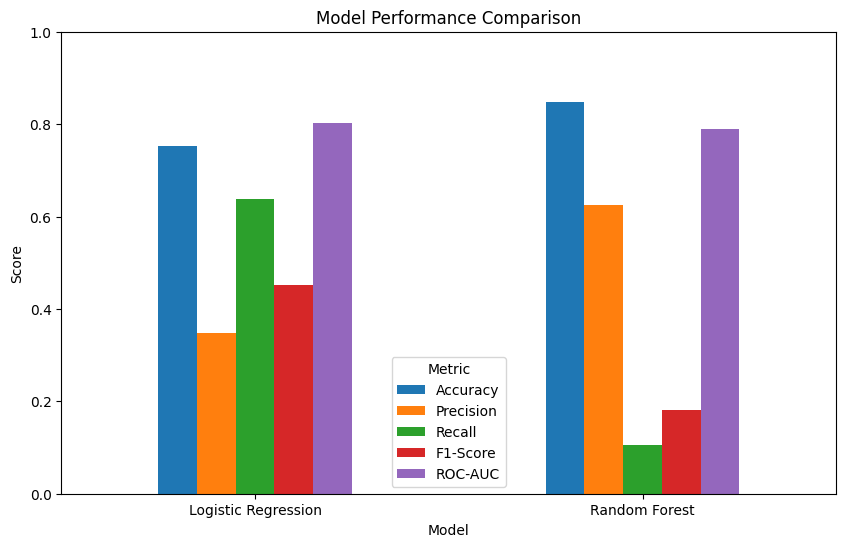

In [18]:


model_comparison.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.show()

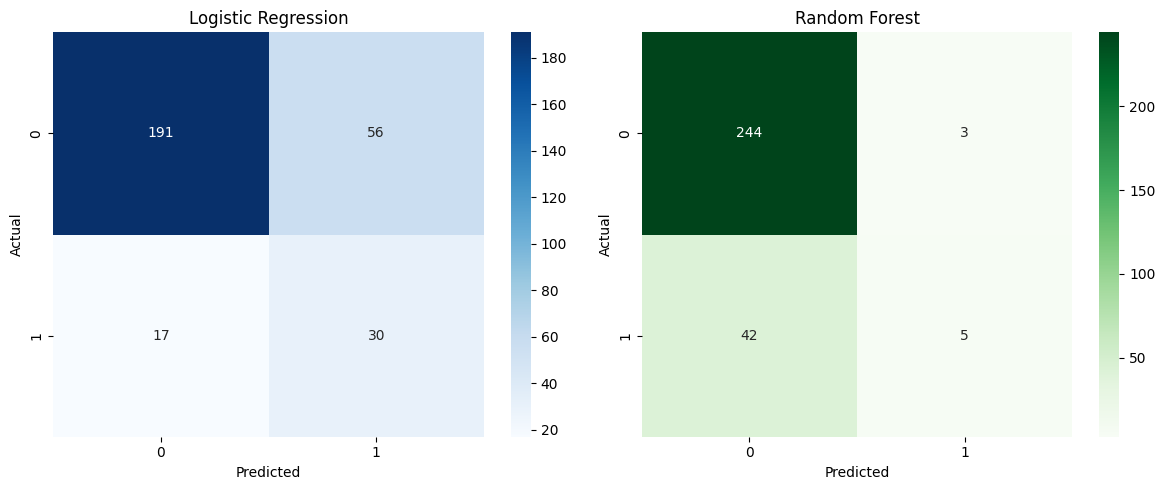

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
sns.heatmap(
    confusion_matrix(y_test, log_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Random Forest
sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[1]
)

axes[1].set_title('Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

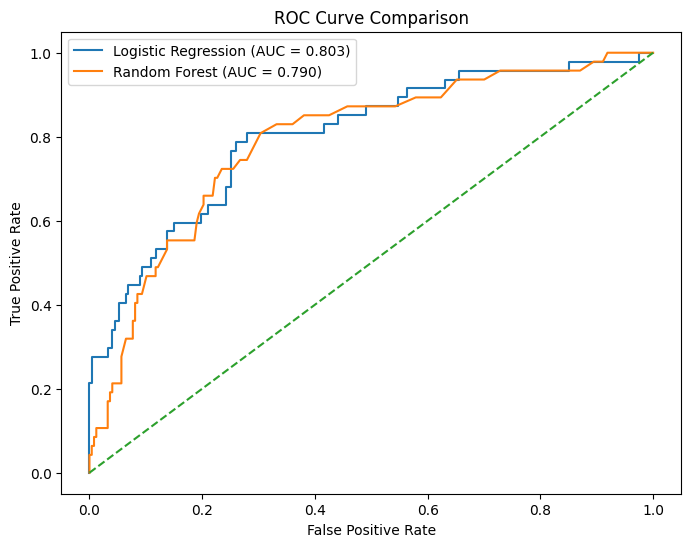

In [20]:
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, log_prob):.3f})'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# Workforce Analytics

In [21]:
# Attrition rate by Job Role

job_role_attrition = (
    df.groupby('JobRole')['Attrition']
    .mean()
    .sort_values(ascending=False)
)

job_role_attrition

JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition, dtype: float64

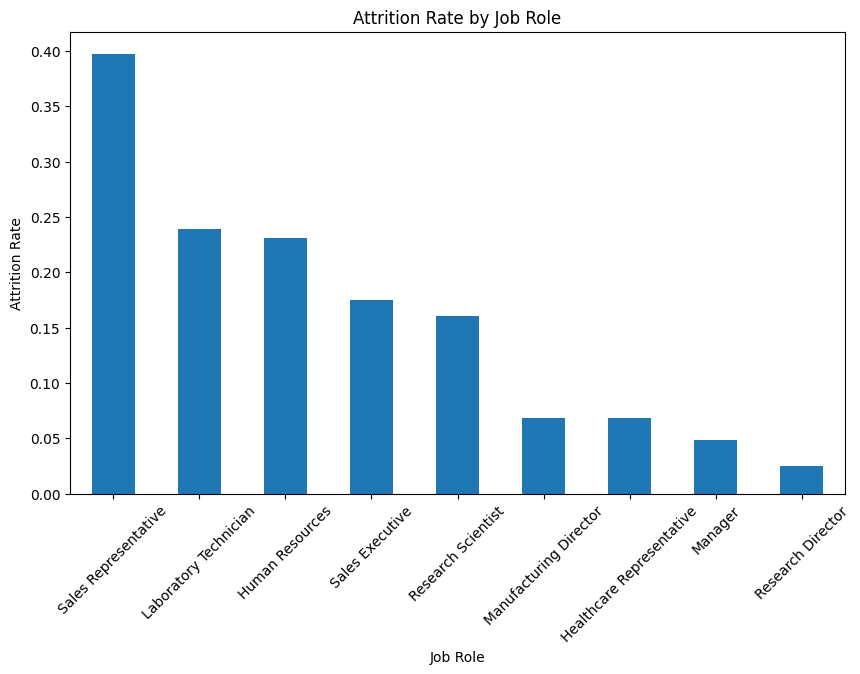

In [22]:
plt.figure(figsize=(10, 6))

job_role_attrition.plot(kind='bar')

plt.title('Attrition Rate by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=45)
plt.show()

In [23]:
# Create three income bands

df['IncomeBand'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 5000, 10000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

income_attrition = (
    df.groupby('IncomeBand', observed=False)['Attrition']
    .mean()
)

income_attrition

IncomeBand
Low       0.217623
Medium    0.111364
High      0.088968
Name: Attrition, dtype: float64

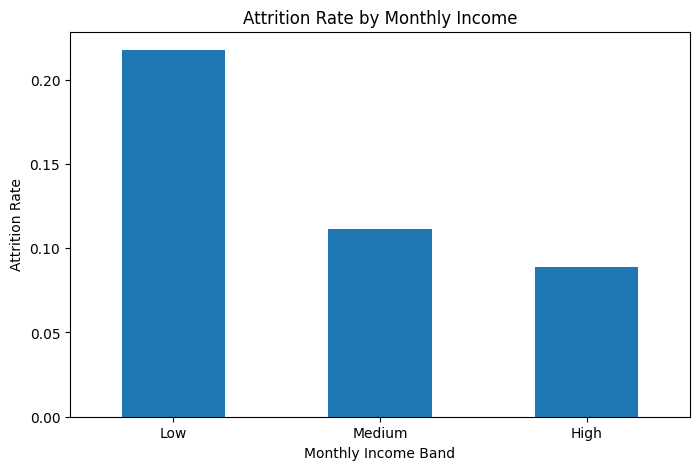

In [24]:
plt.figure(figsize=(8, 5))

income_attrition.plot(kind='bar')

plt.title('Attrition Rate by Monthly Income')
plt.xlabel('Monthly Income Band')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.show()

In [25]:
# Create age groups

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 45, float('inf')],
    labels=['Under 25', '25-35', '36-45', '46+']
)

age_attrition = (
    df.groupby('AgeGroup', observed=False)['Attrition']
    .mean()
)

age_attrition

AgeGroup
Under 25    0.357724
25-35       0.191419
36-45       0.091880
46+         0.124542
Name: Attrition, dtype: float64

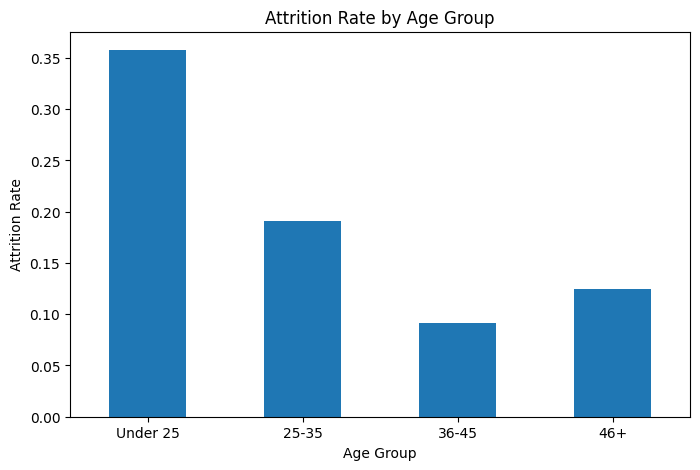

In [26]:
plt.figure(figsize=(8, 5))

age_attrition.plot(kind='bar')

plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.show()

In [27]:
# Attrition rate by Job Satisfaction
satisfaction_attrition = (
    df.groupby('JobSatisfaction')['Attrition']
      .mean()
      .mul(100)
      .reset_index(name='AttritionRate')
)

satisfaction_attrition

,JobSatisfaction,AttritionRate
0,1,22.837370
1,2,16.428571
2,3,16.515837
3,4,11.328976


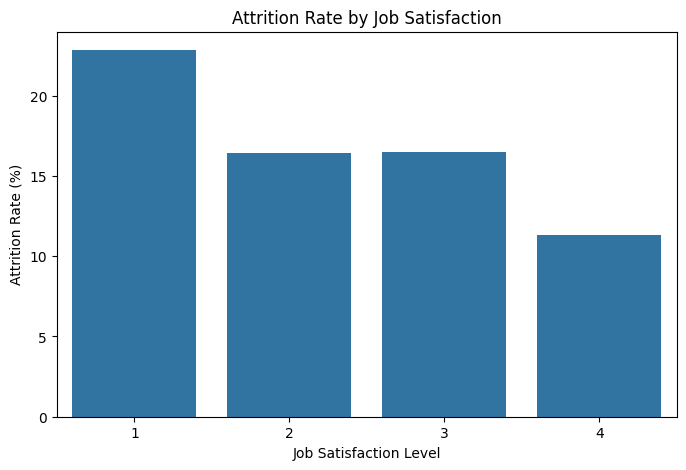

In [28]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=satisfaction_attrition,
    x='JobSatisfaction',
    y='AttritionRate'
)

plt.title('Attrition Rate by Job Satisfaction')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [29]:
promotion_attrition = (
    df.groupby('YearsSinceLastPromotion')['Attrition']
      .mean()
      .mul(100)
      .reset_index(name='AttritionRate')
)

promotion_attrition

,YearsSinceLastPromotion,AttritionRate
0,0,18.932874
1,1,13.725490
2,2,16.981132
3,3,17.307692
4,4,8.196721
5,5,4.444444
6,6,18.750000
7,7,21.052632
8,8,0.000000
9,9,23.529412


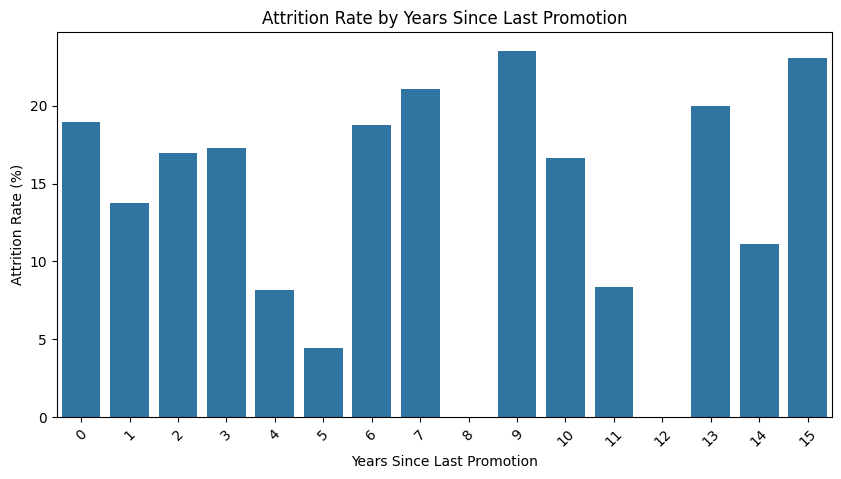

In [30]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=promotion_attrition,
    x='YearsSinceLastPromotion',
    y='AttritionRate'
)

plt.title('Attrition Rate by Years Since Last Promotion')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=45)
plt.show()

In [31]:
overtime_attrition = (
    df.groupby('OverTime')['Attrition']
      .mean()
      .mul(100)
      .reset_index(name='AttritionRate')
)

overtime_attrition

,OverTime,AttritionRate
0,No,10.436433
1,Yes,30.528846


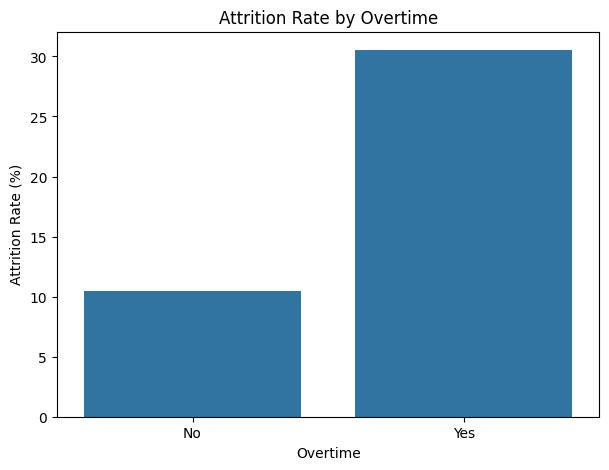

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=overtime_attrition,
    x='OverTime',
    y='AttritionRate'
)

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [33]:
department_attrition = (
    df.groupby('Department')['Attrition']
      .mean()
      .mul(100)
      .reset_index(name='AttritionRate')
)

department_attrition

,Department,AttritionRate
0,Human Resources,19.047619
1,Research & Development,13.839750
2,Sales,20.627803


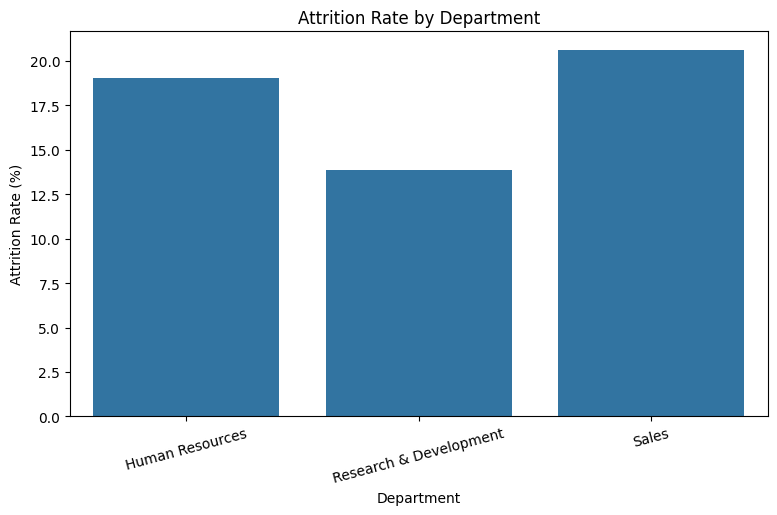

In [34]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=department_attrition,
    x='Department',
    y='AttritionRate'
)

plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=15)
plt.show()

In [35]:
df['TenureGroup'] = pd.cut(
    df['YearsAtCompany'],
    bins=[-1, 2, 5, 10, np.inf],
    labels=['0-2 Years', '3-5 Years', '6-10 Years', '10+ Years']
)

df['TenureGroup'].value_counts().sort_index()

TenureGroup
0-2 Years     342
3-5 Years     434
6-10 Years    448
10+ Years     246
Name: count, dtype: int64

In [36]:
tenure_attrition = (
    df.groupby('TenureGroup', observed=False)['Attrition']
      .mean()
      .mul(100)
      .reset_index(name='AttritionRate')
)

tenure_attrition

,TenureGroup,AttritionRate
0,0-2 Years,29.824561
1,3-5 Years,13.824885
2,6-10 Years,12.276786
3,10+ Years,8.130081


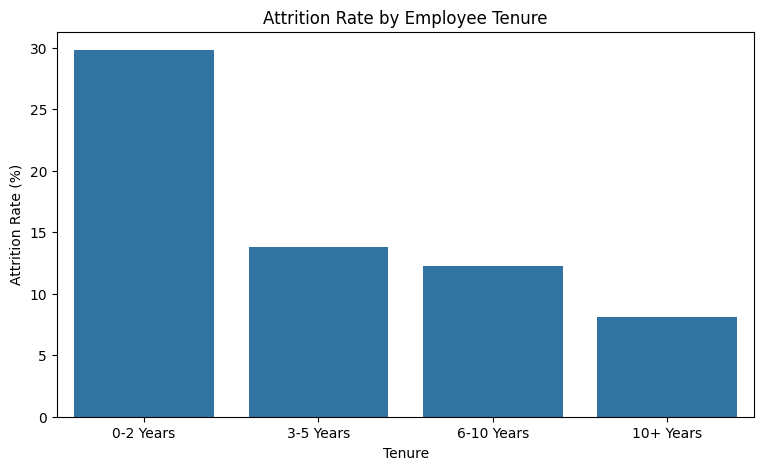

In [37]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tenure_attrition,
    x='TenureGroup',
    y='AttritionRate'
)

plt.title('Attrition Rate by Employee Tenure')
plt.xlabel('Tenure')
plt.ylabel('Attrition Rate (%)')
plt.show()

In [38]:
# Create model input using only the features used during training
model_features = X.columns.tolist()

df['AttritionProbability'] = logistic_model.predict_proba(
    df[model_features]
)[:, 1]

In [41]:
def get_risk_level(probability):
    if probability < 0.30:
        return "Low"
    elif probability < 0.60:
        return "Medium"
    else:
        return "High"

In [42]:
df['RiskLevel'] = df['AttritionProbability'].apply(get_risk_level)

In [43]:
df['RiskLevel'].value_counts()

RiskLevel
Low       765
Medium    363
High      342
Name: count, dtype: int64

In [44]:
df[['AttritionProbability', 'RiskLevel']].head(10)

,AttritionProbability,RiskLevel
0,0.901435,High
1,0.106928,Low
2,0.753190,High
3,0.372922,Medium
4,0.829327,High
5,0.274509,Low
6,0.430128,Medium
7,0.314538,Medium
8,0.344972,Medium
9,0.157733,Low


In [45]:
df['RiskScore'] = (df['AttritionProbability'] * 100).round(2)

In [46]:
# View high-risk employees

high_risk_employees = df[
    df['RiskLevel'] == 'High'
].copy()

high_risk_employees[
    [
        'Age',
        'JobRole',
        'Department',
        'MonthlyIncome',
        'JobSatisfaction',
        'OverTime',
        'YearsSinceLastPromotion',
        'AttritionProbability',
        'RiskLevel'
    ]
].sort_values(
    by='AttritionProbability',
    ascending=False
).head(10)

,Age,JobRole,Department,MonthlyIncome,JobSatisfaction,OverTime,YearsSinceLastPromotion,AttritionProbability,RiskLevel
357,21,Sales Representative,Sales,2174,2,Yes,1,0.991705,High
1060,24,Laboratory Technician,Research & Development,3172,1,Yes,0,0.991066,High
463,26,Laboratory Technician,Research & Development,2340,4,Yes,0,0.989617,High
911,25,Sales Representative,Sales,1118,4,Yes,1,0.987143,High
1057,29,Sales Executive,Sales,5765,2,No,0,0.983632,High
457,18,Sales Representative,Sales,1878,2,Yes,0,0.980921,High
1396,53,Sales Executive,Sales,10448,1,Yes,2,0.973652,High
798,33,Research Scientist,Research & Development,2313,2,Yes,2,0.972429,High
656,32,Laboratory Technician,Research & Development,2795,4,Yes,0,0.972060,High
14,28,Laboratory Technician,Research & Development,2028,3,Yes,0,0.971618,High


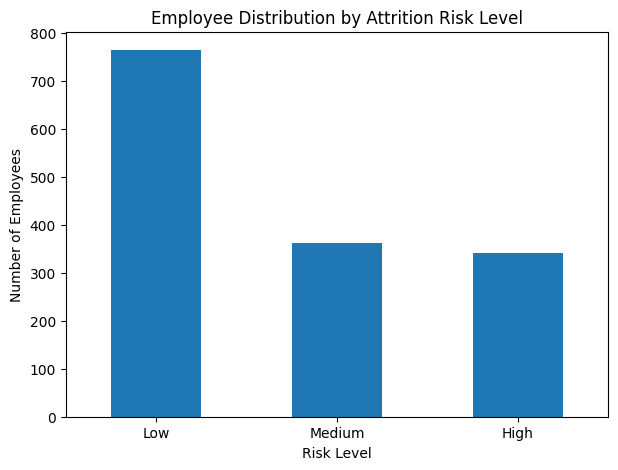

In [47]:
# Employee distribution by risk level

risk_distribution = df['RiskLevel'].value_counts()

plt.figure(figsize=(7, 5))

risk_distribution.plot(kind='bar')

plt.title('Employee Distribution by Attrition Risk Level')
plt.xlabel('Risk Level')
plt.ylabel('Number of Employees')
plt.xticks(rotation=0)
plt.show()

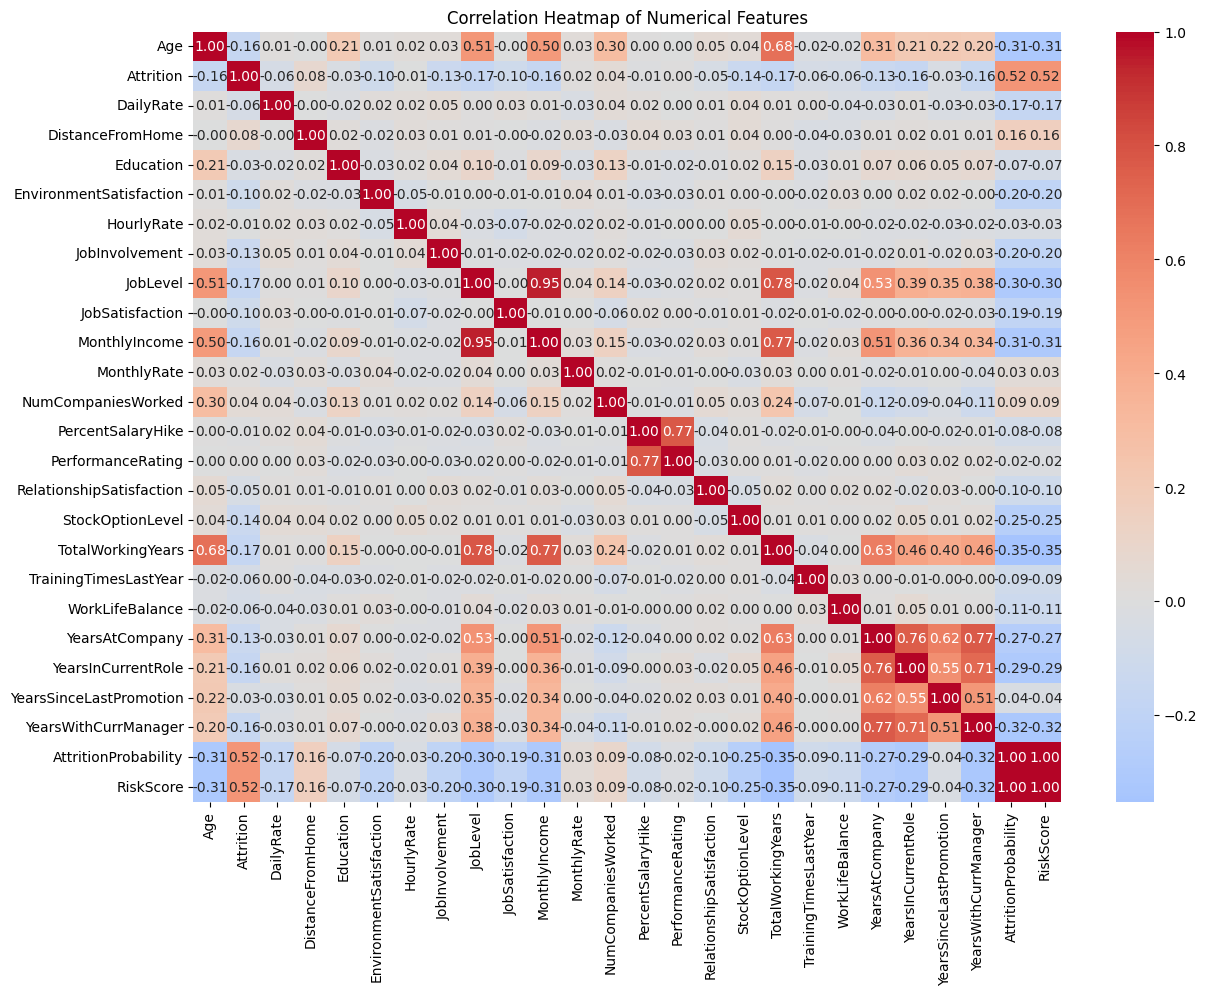

In [54]:
# Correlation with Attrition

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

correlation = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    correlation,
    cmap='coolwarm',
    annot=True,
    center=0,
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#  Feature Importance and Attrition Drivers

In [49]:
# Get the trained preprocessor and logistic regression model
trained_preprocessor = logistic_model.named_steps['preprocessor']
trained_model = logistic_model.named_steps['model']

# Get transformed feature names
feature_names = trained_preprocessor.get_feature_names_out()

# Get coefficients
coefficients = trained_model.coef_[0]

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance': np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Importance
42,cat__JobRole_Research Director,-1.465683,1.465683
39,cat__JobRole_Laboratory Technician,1.194333,1.194333
45,cat__JobRole_Sales Representative,1.120617,1.120617
23,cat__BusinessTravel_Non-Travel,-0.993885,0.993885
49,cat__OverTime_No,-0.892809,0.892809
33,cat__EducationField_Other,-0.798108,0.798108
24,cat__BusinessTravel_Travel_Frequently,0.787566,0.787566
50,cat__OverTime_Yes,0.761522,0.761522
29,cat__EducationField_Human Resources,0.721129,0.721129
37,cat__JobRole_Healthcare Representative,-0.647202,0.647202


In [50]:
feature_importance['Feature'] = (
    feature_importance['Feature']
    .str.replace('num__', '', regex=False)
    .str.replace('cat__', '', regex=False)
)

feature_importance.head(15)

,Feature,Coefficient,Importance
42,JobRole_Research Director,-1.465683,1.465683
39,JobRole_Laboratory Technician,1.194333,1.194333
45,JobRole_Sales Representative,1.120617,1.120617
23,BusinessTravel_Non-Travel,-0.993885,0.993885
49,OverTime_No,-0.892809,0.892809
33,EducationField_Other,-0.798108,0.798108
24,BusinessTravel_Travel_Frequently,0.787566,0.787566
50,OverTime_Yes,0.761522,0.761522
29,EducationField_Human Resources,0.721129,0.721129
37,JobRole_Healthcare Representative,-0.647202,0.647202


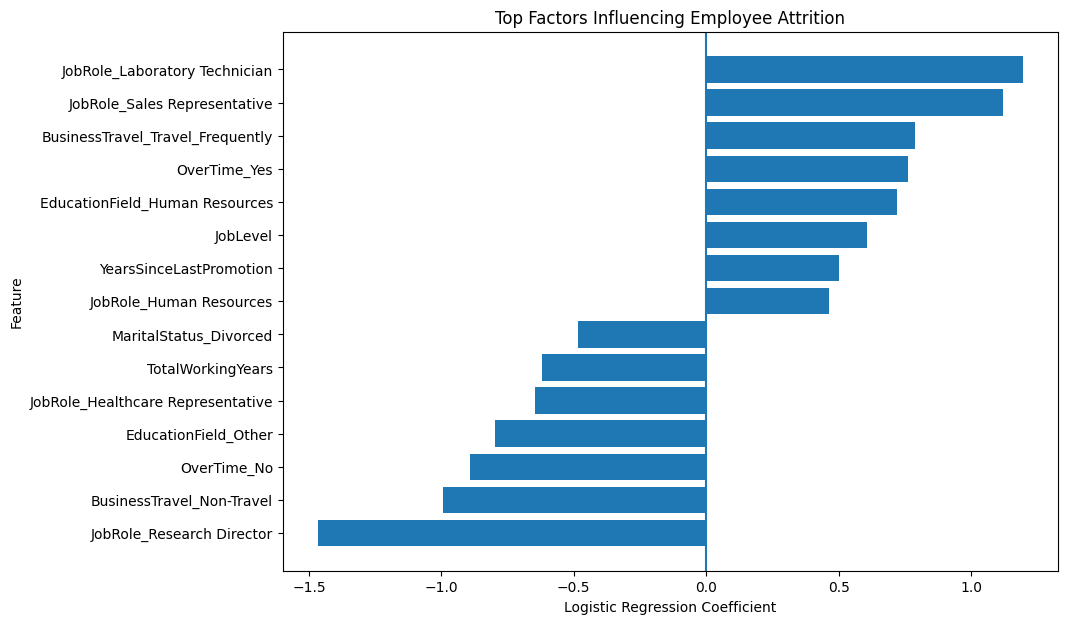

In [56]:
top_features = feature_importance.head(15).sort_values(
    by='Coefficient'
)

plt.figure(figsize=(10, 7))
plt.barh(top_features['Feature'], top_features['Coefficient'])

plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.title('Top Factors Influencing Employee Attrition')
plt.axvline(x=0)
plt.show()

### Interpretation

The Logistic Regression coefficients indicate which features are associated with the model's predicted attrition probability.

- Positive coefficients are associated with higher predicted attrition probability.
- Negative coefficients are associated with lower predicted attrition probability.
- Larger absolute coefficient values indicate a stronger contribution to the model's prediction.

These relationships represent model associations and should not be interpreted as proof that a feature directly causes employee attrition.

In [58]:
# reusable employee risk predictor
def predict_employee_risk(employee_data):
    
    employee_df = pd.DataFrame([employee_data])
    
    probability = logistic_model.predict_proba(
        employee_df
    )[0][1]
    
    risk_level = get_risk_level(probability)
    
    return {
        "attrition_probability": round(probability * 100, 2),
        "risk_level": risk_level
    }

In [59]:
results = []

for index, row in X_test.head(10).iterrows():
    
    result = predict_employee_risk(row.to_dict())
    
    results.append({
        "Employee Index": index,
        "Actual Attrition": y_test.loc[index],
        "Predicted Probability": result["attrition_probability"],
        "Risk Level": result["risk_level"]
    })

results_df = pd.DataFrame(results)

results_df

,Employee Index,Actual Attrition,Predicted Probability,Risk Level
0,1061,0,28.66,Low
1,891,0,2.19,Low
2,456,0,40.76,Medium
3,922,0,4.04,Low
4,69,1,67.41,High
5,1164,0,64.23,High
6,406,0,8.08,Low
7,1330,0,15.03,Low
8,1232,0,2.05,Low
9,1311,0,23.78,Low


In [67]:
def simulate_employee_changes(employee_data, changes):
    
    # Create a copy so original employee data is not modified
    modified_employee = employee_data.copy()
    
    # Apply the changes
    for feature, new_value in changes.items():
        modified_employee[feature] = new_value
    
    # Original prediction
    original_result = predict_employee_risk(employee_data)
    
    # New prediction after changes
    new_result = predict_employee_risk(modified_employee)
    
    # Calculate change in risk
    risk_change = round(
        new_result["attrition_probability"]
        - original_result["attrition_probability"],
        2
    )
    
    return {
        "original_probability": float(original_result["attrition_probability"]),
        "original_risk": original_result["risk_level"],
        
        "new_probability": float(new_result["attrition_probability"]),
        "new_risk": new_result["risk_level"],
        
        "risk_change": float(risk_change)
    }

In [68]:
employee = X_test.iloc[0].to_dict()
changes = {
    'OverTime': 'No',
    'JobSatisfaction': 4,
    'WorkLifeBalance': 4,
    'YearsSinceLastPromotion': 1
}

simulation_result = simulate_employee_changes(
    employee,
    changes
)

simulation_result

{'original_probability': 28.66,
 'original_risk': 'Low',
 'new_probability': 14.58,
 'new_risk': 'Low',
 'risk_change': -14.08}

In [69]:
print("WHAT-IF SIMULATION RESULTS\n")

print(
    f"Original Risk: "
    f"{simulation_result['original_probability']}% "
    f"({simulation_result['original_risk']})"
)

print(
    f"New Risk: "
    f"{simulation_result['new_probability']}% "
    f"({simulation_result['new_risk']})"
)

print(
    f"Risk Change: "
    f"{simulation_result['risk_change']} percentage points"
)

WHAT-IF SIMULATION RESULTS

Original Risk: 28.66% (Low)
New Risk: 14.58% (Low)
Risk Change: -14.08 percentage points


In [70]:


joblib.dump(logistic_model, 'attrition_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [71]:
import os

print(os.listdir())

['.virtual_documents', 'attrition_model.pkl']


In [73]:
loaded_model = joblib.load('attrition_model.pkl')

test_employee = X_test.iloc[0:1]

prediction = loaded_model.predict_proba(test_employee)[0][1]

print(f"Loaded model prediction: {prediction:.2%}")

Loaded model prediction: 28.66%


# Conclusion

This project developed an Employee Attrition Prediction and Workforce Analytics System using machine learning and HR data.

The project:
- Performed data preprocessing and exploratory workforce analysis.
- Compared Logistic Regression and Random Forest using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
- Analyzed attrition patterns across job roles, income bands, and age groups.
- Used feature importance to understand which factors contribute most to model predictions.
- Converted predicted attrition probabilities into Low, Medium, and High risk categories.
- Identified employees with higher predicted attrition risk for further review.
- Included a what-if analysis to examine how hypothetical changes in selected employee attributes affect the model's predicted attrition probability.

The system can support HR teams by providing a data-driven way to identify patterns and prioritize employees for further review and retention analysis. The predictions should be treated as decision-support information rather than definitive predictions of individual employee behavior.